#### Imports

In [1]:
import numpy as np
import pandas as pd
import pickle
from collections import Counter

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append('../')

from src.chunking import chunk_text, chunk_texts, aggregate_chunk_embeddings

### Configuration

In [3]:
CHUNK_SIZE = 150
OVERLAP = 20
MAX_CHUNKS = 15
MODEL_NAME = "FremyCompany/BioLORD-2023"
AGGREGATION = "mean_max"  # best strategy from notebook 03

### Load retrieval split and chunk texts

In [4]:
# # Colab only
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
# # Colab only
# with open("/content/drive/MyDrive/Colab Notebooks/Projects/rare_disease_diagnosis/dataset/split_retrieval.pkl", "rb") as f:
#     X_train_ret, X_test_ret, y_train_ret, y_test_ret = pickle.load(f)

# Local
with open("../data/split_retrieval.pkl", "rb") as f:
    X_train_ret, X_test_ret, y_train_ret, y_test_ret = pickle.load(f)

print(f"Train: {len(X_train_ret)}  |  Test: {len(X_test_ret)}")
print(f"Train classes: {y_train_ret.nunique()}  |  Test classes: {y_test_ret.nunique()}")

Train: 5532  |  Test: 1383
Train classes: 942  |  Test classes: 530


In [7]:
# Chunk train and test texts
train_chunks, train_doc_lengths = chunk_texts(
    X_train_ret, chunk_size=CHUNK_SIZE, overlap=OVERLAP, max_chunks=MAX_CHUNKS
)
test_chunks, test_doc_lengths = chunk_texts(
    X_test_ret, chunk_size=CHUNK_SIZE, overlap=OVERLAP, max_chunks=MAX_CHUNKS
)

print(f"Train: {len(X_train_ret)} docs → {len(train_chunks)} chunks "
      f"(avg {len(train_chunks)/len(X_train_ret):.1f} chunks/doc)")
print(f"Test:  {len(X_test_ret)} docs → {len(test_chunks)} chunks "
      f"(avg {len(test_chunks)/len(X_test_ret):.1f} chunks/doc)")

Train: 5532 docs → 16536 chunks (avg 3.0 chunks/doc)
Test:  1383 docs → 4260 chunks (avg 3.1 chunks/doc)


### Generate chunk embeddings and aggregate (Colab only)

Run this section on Colab with GPU. It generates chunk-level BioLORD embeddings, aggregates them per document using mean_max pooling, and saves the result.

In [6]:
# !git clone https://github.com/amlopeza/rare_disease_diagnosis.git

In [7]:
# %cd rare_disease_diagnosis

In [8]:
# # Colab only: generate chunk embeddings
# from src.embeddings import load_model, generate_embeddings

# model = load_model(MODEL_NAME)

# train_chunk_embs = generate_embeddings(train_chunks, model=model, batch_size=64)
# test_chunk_embs = generate_embeddings(test_chunks, model=model, batch_size=64)

# print(f"Train chunk embeddings: {train_chunk_embs.shape}")
# print(f"Test chunk embeddings:  {test_chunk_embs.shape}")

In [ ]:
# # Colab only: aggregate chunks to document-level embeddings (mean_max)
# X_train_emb = aggregate_chunk_embeddings(train_chunk_embs, train_doc_lengths, method=AGGREGATION)
# X_test_emb = aggregate_chunk_embeddings(test_chunk_embs, test_doc_lengths, method=AGGREGATION)
#
# print(f"Train doc embeddings: {X_train_emb.shape}")
# print(f"Test doc embeddings:  {X_test_emb.shape}")

In [9]:
# # Colab only: save aggregated embeddings
# import os

# BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/Projects/rare_disease_diagnosis/dataset/"
# output_path = os.path.join(BASE_PATH, "embeddings_biolord_chunked_retrieval.pkl")

# with open(output_path, "wb") as f:
#     pickle.dump({
#         "X_train_emb": X_train_emb,
#         "X_test_emb": X_test_emb,
#         "y_train": y_train_ret,
#         "y_test": y_test_ret,
#         "train_doc_lengths": train_doc_lengths,
#         "test_doc_lengths": test_doc_lengths,
#         "config": {
#             "chunk_size": CHUNK_SIZE,
#             "overlap": OVERLAP,
#             "max_chunks": MAX_CHUNKS,
#             "model_name": MODEL_NAME,
#             "aggregation": AGGREGATION,
#         }
#     }, f)

# print(f"Saved: {output_path}")

#### Load pre-computed embeddings (local)

In [10]:
path = "../data/embeddings_biolord_chunked_retrieval.pkl"

with open(path, "rb") as f:
    data = pickle.load(f)

X_train_emb = data["X_train_emb"]
X_test_emb = data["X_test_emb"]
y_train = data["y_train"]
y_test = data["y_test"]
config = data["config"]

print(f"Config: {config}")
print(f"Train: {X_train_emb.shape}  |  Test: {X_test_emb.shape}")
print(f"Train classes: {y_train.nunique()}  |  Test classes: {y_test.nunique()}")

Config: {'chunk_size': 150, 'overlap': 20, 'max_chunks': 15, 'model_name': 'FremyCompany/BioLORD-2023', 'aggregation': 'mean_max'}
Train: (5532, 1536)  |  Test: (1383, 1536)
Train classes: 942  |  Test classes: 530


#### Filter test set: remove queries with no train representative

Test samples whose disease never appears in train are unanswerable by design -- the correct diagnosis does not exist in the search index. We exclude them for a fair evaluation.

In [11]:
train_classes = set(y_train)
test_mask = y_test.isin(train_classes).values

X_test_eval = X_test_emb[test_mask]
y_test_eval = y_test[test_mask].reset_index(drop=True)

n_excluded = (~test_mask).sum()
print(f"Test samples excluded (class not in train): {n_excluded}")
print(f"Evaluable test samples: {len(y_test_eval)} / {len(y_test)}")
print(f"Evaluable test classes: {y_test_eval.nunique()}")

Test samples excluded (class not in train): 82
Evaluable test samples: 1301 / 1383
Evaluable test classes: 460


### k-NN Retrieval Benchmark

Index all train embeddings, query with each test sample, retrieve the k nearest neighbors and check if the correct diagnosis appears among their labels.

**Note:** mean_max embeddings are 1536-dim (768 mean + 768 max concatenated). Cosine similarity still works well as the metric since both halves are L2-normalized independently.

In [12]:
K_MAX = 20  # retrieve enough neighbors for all metrics

nn = NearestNeighbors(n_neighbors=K_MAX, metric="cosine")
nn.fit(X_train_emb)

distances, indices = nn.kneighbors(X_test_eval)

# Map neighbor indices to their disease labels
y_train_arr = y_train.values
retrieved_labels = y_train_arr[indices]  # shape: (n_test_eval, K_MAX)

print(f"Retrieved labels shape: {retrieved_labels.shape}")

Retrieved labels shape: (1301, 20)


#### Metrics: Hit@k and MRR

In [13]:
y_true = y_test_eval.values

def hit_at_k(y_true, retrieved_labels, k):
    """Fraction of queries where the correct label appears in top-k."""
    return np.mean([y_true[i] in retrieved_labels[i, :k]
                    for i in range(len(y_true))])

def mrr(y_true, retrieved_labels):
    """Mean Reciprocal Rank: average of 1/rank of first correct hit."""
    rr = []
    for i in range(len(y_true)):
        positions = np.where(retrieved_labels[i] == y_true[i])[0]
        if len(positions) > 0:
            rr.append(1.0 / (positions[0] + 1))
        else:
            rr.append(0.0)
    return np.mean(rr)

# Compute metrics
ks = [1, 3, 5, 10, 20]
hits = {k: hit_at_k(y_true, retrieved_labels, k) for k in ks}
mrr_score = mrr(y_true, retrieved_labels)

print("=" * 60)
print("Retrieval Benchmark — BioLORD chunked (mean_max) + k-NN (cosine)")
print("=" * 60)
for k, h in hits.items():
    print(f"  Hit@{k:<3}: {h:.4f}")
print(f"  MRR:    {mrr_score:.4f}")
print("=" * 60)

Retrieval Benchmark — BioLORD chunked (mean_max) + k-NN (cosine)
  Hit@1  : 0.1414
  Hit@3  : 0.2606
  Hit@5  : 0.3251
  Hit@10 : 0.4304
  Hit@20 : 0.5204
  MRR:    0.2270


#### Hit@k curve

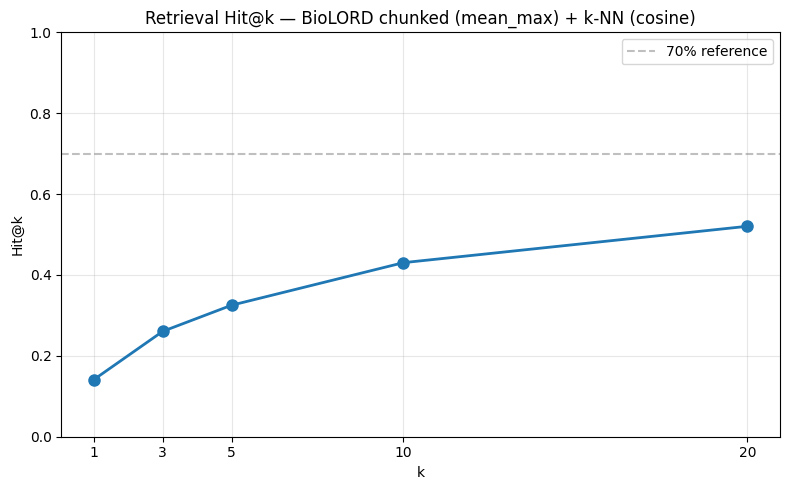

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(hits.keys()), list(hits.values()), "o-", linewidth=2, markersize=8)
ax.set_xlabel("k")
ax.set_ylabel("Hit@k")
ax.set_title("Retrieval Hit@k — BioLORD chunked (mean_max) + k-NN (cosine)")
ax.set_xticks(list(hits.keys()))
ax.set_ylim(0, 1)
ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5, label="70% reference")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Hit@10 breakdown by class frequency

Are rare diseases (few train samples) harder to retrieve than common ones?

freq_bin  hit_at_10  n_queries
       1   0.120000         75
     2-3   0.242857        140
     4-5   0.383333        120
    6-10   0.349794        243
   11-20   0.423387        248
     21+   0.591579        475


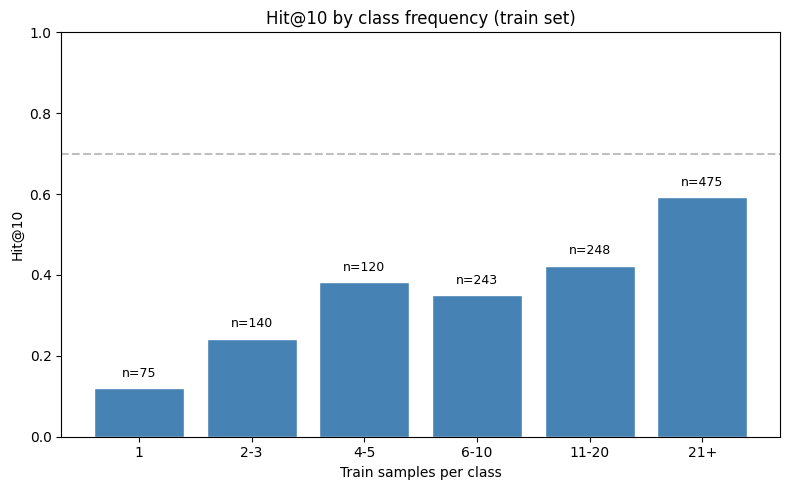

In [15]:
train_counts = y_train.value_counts().to_dict()

# Per-query: train frequency of the true label + hit@10 flag
results_df = pd.DataFrame({
    "true_label": y_true,
    "train_freq": [train_counts.get(y, 0) for y in y_true],
    "hit_at_10": [y_true[i] in retrieved_labels[i, :10] for i in range(len(y_true))],
})

# Bin by train frequency
bins = [0, 1, 3, 5, 10, 20, np.inf]
labels_bin = ["1", "2-3", "4-5", "6-10", "11-20", "21+"]
results_df["freq_bin"] = pd.cut(results_df["train_freq"], bins=bins, labels=labels_bin)

# Hit@10 per bin
freq_hit = results_df.groupby("freq_bin", observed=False).agg(
    hit_at_10=("hit_at_10", "mean"),
    n_queries=("hit_at_10", "count"),
).reset_index()

print(freq_hit.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(freq_hit["freq_bin"].astype(str), freq_hit["hit_at_10"], color="steelblue", edgecolor="white")
ax.set_xlabel("Train samples per class")
ax.set_ylabel("Hit@10")
ax.set_title("Hit@10 by class frequency (train set)")
ax.set_ylim(0, 1)
ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5)

# Annotate bar with query count
for i, row in freq_hit.iterrows():
    ax.text(i, row["hit_at_10"] + 0.02, f'n={row["n_queries"]}',
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

#### Cosine similarity distribution: correct vs incorrect retrievals

If the embeddings separate diseases well, the similarity to correct matches should be clearly higher than to incorrect ones.

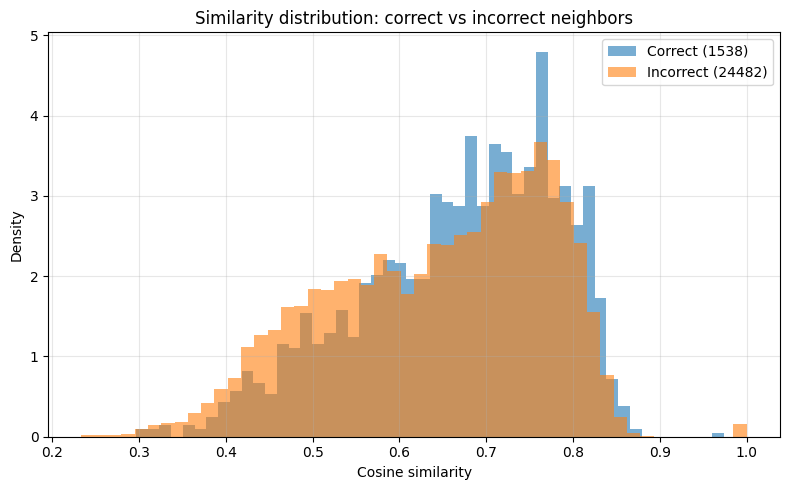

Mean similarity — correct: 0.6685  |  incorrect: 0.6451


In [16]:
# cosine_distance = 1 - cosine_similarity, so similarity = 1 - distance
similarities = 1 - distances  # shape: (n_test_eval, K_MAX)

correct_sims = []
incorrect_sims = []

for i in range(len(y_true)):
    for j in range(K_MAX):
        if retrieved_labels[i, j] == y_true[i]:
            correct_sims.append(similarities[i, j])
        else:
            incorrect_sims.append(similarities[i, j])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(correct_sims, bins=50, alpha=0.6, label=f"Correct ({len(correct_sims)})", density=True)
ax.hist(incorrect_sims, bins=50, alpha=0.6, label=f"Incorrect ({len(incorrect_sims)})", density=True)
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Density")
ax.set_title("Similarity distribution: correct vs incorrect neighbors")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean similarity — correct: {np.mean(correct_sims):.4f}  |  incorrect: {np.mean(incorrect_sims):.4f}")

#### Majority-vote Hit@k

Instead of checking if any of the top-k neighbors has the correct label, use majority vote: the predicted diagnosis is the most frequent label among the k neighbors.

In [17]:
def majority_vote_accuracy(y_true, retrieved_labels, k):
    """Accuracy when predicting the most frequent label among top-k neighbors."""
    correct = 0
    for i in range(len(y_true)):
        top_k = retrieved_labels[i, :k]
        pred = Counter(top_k).most_common(1)[0][0]
        if pred == y_true[i]:
            correct += 1
    return correct / len(y_true)

vote_ks = [1, 3, 5, 10, 20]
vote_acc = {k: majority_vote_accuracy(y_true, retrieved_labels, k) for k in vote_ks}

print("Majority-vote accuracy:")
for k, a in vote_acc.items():
    print(f"  k={k:<3}: {a:.4f}")

Majority-vote accuracy:
  k=1  : 0.1414
  k=3  : 0.1483
  k=5  : 0.1622
  k=10 : 0.1776
  k=20 : 0.1783


#### Summary table

In [18]:
summary = pd.DataFrame({
    "Metric": [f"Hit@{k}" for k in ks] + ["MRR"] + [f"MajVote@{k}" for k in vote_ks],
    "Score": [hits[k] for k in ks] + [mrr_score] + [vote_acc[k] for k in vote_ks],
})
summary["Score"] = summary["Score"].map("{:.4f}".format)
print(summary.to_string(index=False))

    Metric  Score
     Hit@1 0.1414
     Hit@3 0.2606
     Hit@5 0.3251
    Hit@10 0.4304
    Hit@20 0.5204
       MRR 0.2270
 MajVote@1 0.1414
 MajVote@3 0.1483
 MajVote@5 0.1622
MajVote@10 0.1776
MajVote@20 0.1783


### Summary and Analysis

**Setup:** BioLORD-2023 chunked embeddings (mean_max aggregation, 1536-dim) from the retrieval split + k-NN cosine retrieval over 460 evaluable test classes (82 test samples excluded — their disease has no train representative). Chunking config: chunk_size=150, overlap=20, max_chunks=15.

#### Key results

| Metric | Flat BioLORD | Chunked mean_max | Delta |
|---|---|---|---|
| Hit@1 | 0.1184 | 0.1414 | +2.3pp |
| Hit@5 | 0.2767 | 0.3251 | +4.8pp |
| Hit@10 | 0.3774 | 0.4304 | +5.3pp |
| Hit@20 | 0.4766 | 0.5204 | +4.4pp |
| MRR | 0.1937 | 0.2270 | +3.3pp |

#### What these numbers tell us

**1. Chunked mean_max improves retrieval across the board.** The same pattern seen in the classification task (notebook 03) carries over to retrieval: preserving chunk-level information via mean_max pooling reduces signal dilution and yields better neighbors. Hit@10 goes from 38% to 43%.

**2. The improvement is consistent but the absolute performance remains low.** Even with chunking, Hit@10 at 43% is well below the 60–70% range that would indicate a strong retrieval baseline. The embedding space still lacks fine-grained disease-level discriminability.

**3. Majority vote still barely helps.** MajVote@10 (0.178) is much lower than Hit@10 (0.430), confirming that when the correct disease appears in the top-10 neighbors, it's usually a minority among many different diseases — the neighborhood remains noisy.

#### Conclusions and next steps

1. **Chunked mean_max is the better embedding strategy** for retrieval over flat BioLORD. All future retrieval experiments should use this as the baseline.
2. **Fine-tuning remains the most promising next step.** Contrastive learning (triplet or supervised contrastive loss) with "same diagnosis = positive pair" would reshape the embedding space specifically for disease discrimination.
3. **LLM-based re-ranking** over the top-k candidates is another viable path — retrieve noisy candidates with embeddings, then let an LLM reason over the full clinical text to re-rank.
4. **Consider testing other embedding models** (PubMedBERT, BioLinkBERT, e5-large-v2) before investing in fine-tuning.